# 05. 가설 3 — 고BMI 집단의 흡연이 건강에 더 악영향을 줄 것이다

> 이 노트북은 원본 통합 노트북 `소스_코드_8팀_생체_신호_기반_흡연_여부_비교_시각화_프로젝트__-_종합.ipynb` 의 관련 셀들을 주제별로 재구성한 것입니다. 코드는 원본 그대로 옮겨왔으며(실행 결과만 초기화), 새로 작성하거나 수정한 로직은 없습니다.
>
> 실행하려면 `train_dataset.csv`(Kaggle: Smoker Status Prediction Dataset)를 동일 폴더에 두어야 합니다. 데이터 파일은 저장소에 포함되어 있지 않습니다.
>
> 원본에는 서로 다른 시점에 작성된 3개의 전처리 버전이 섞여 있습니다 (자세한 내용은 `docs/03_issues_and_troubleshooting.md` 참고). 이 재구성본은 그 버전들을 **삭제하거나 하나로 합치지 않고**, 각 노트북 안에서 '버전 A/B/C'로 구분해 모두 보존했습니다.

> 참고: 원래 계획서의 '가설 6(고BMI 집단에서 흡연 영향이 더 크다)'은 단순 비교로는 뒷받침되지 않아 기각되었고, 대신 상호작용항(`smoking * high_BMI`)을 포함한 회귀분석으로 재설계된 것이 이 '가설 3'입니다. 자세한 경위는 `docs/03_issues_and_troubleshooting.md`를 참고하세요.

> ### ⚠️ 실행 순서 주의 — 파일 순서대로 돌리면 안 됩니다
>
> 이 노트북들은 원본 통합 노트북을 **주제별로** 재배치한 것이라,
> `01 → 02 → … → 06` 순서로 실행하면 변수 정의 순서가 깨집니다.
>
> 구체적으로 — `01` 의 **버전 B** 절이 `train = pd.read_csv(...)` 로 데이터를 다시 읽어
> **버전 A 에서 만든 `BMI_group` 컬럼을 지웁니다.** 그 상태로 `03` 을 실행하면
> `KeyError: 'BMI_group'` 이 납니다. (실제로 확인했습니다 — 파일 순서 실행 시 에러 47건)
>
> **이 노트북에 담긴 출력은 원본 통합 노트북의 셀 순서대로 실행해 얻은 것입니다.**
> 원본 코드셀 106개 중 105개가 매칭됐고, **실행 에러 0건 · 그래프 81개**가 재현됐습니다.
>
> 직접 재현하려면 `원본/소스_코드_8팀….ipynb` 를 순서대로 실행하거나,
> 각 절을 독립적으로 돌리려면 그 절 앞에서 데이터를 다시 읽고 파생 컬럼을 재생성해야 합니다.
>
> 데이터: `data/train_dataset.csv` (저장소 미포함 — [`data/README.md`](../../data/README.md))


## 버전 A — BMI 구간별 GTP/중성지방/AST/ALT/허리둘레/HDL, 통합 히트맵

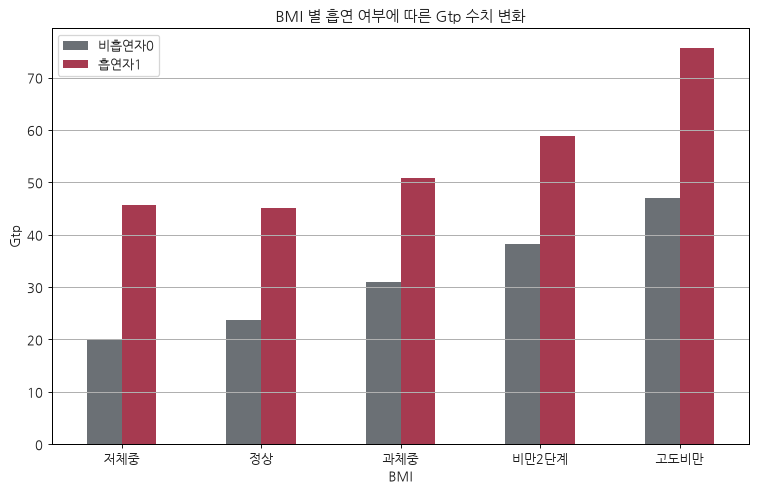

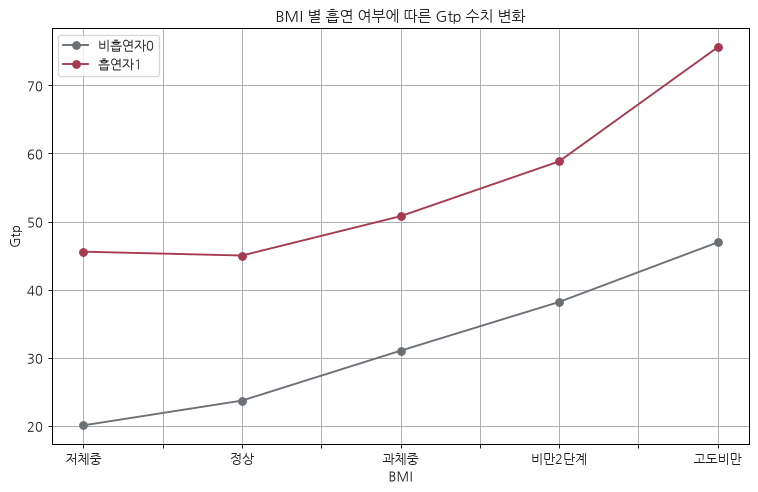

In [ ]:
#가설3 고BMI집단이라는 변수와 흡연이 결합하면 건강에 더 악영향을 줄 것이다
bmi_smoking_gtp = train.groupby(['BMI_group', 'smoking'])['Gtp'].mean().unstack()
bmi_smoking_gtp.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 Gtp 수치 변화')
plt.xlabel('BMI')
plt.ylabel('Gtp')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 Gtp 수치 변화")
plt.xlabel("BMI")
plt.ylabel("Gtp")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

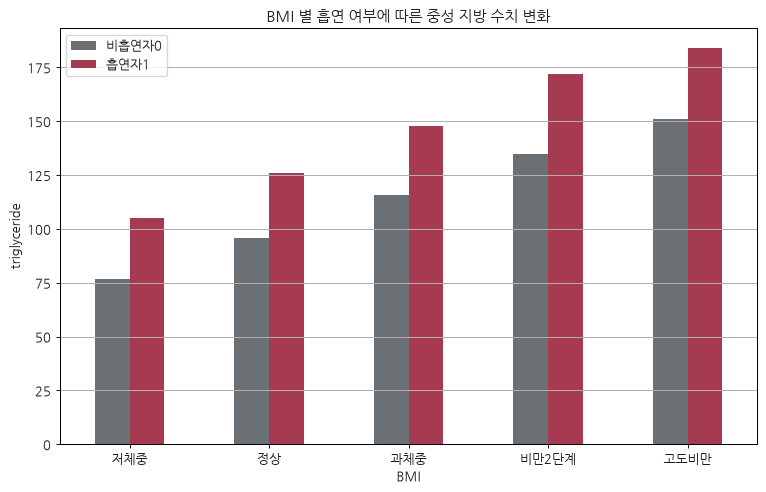

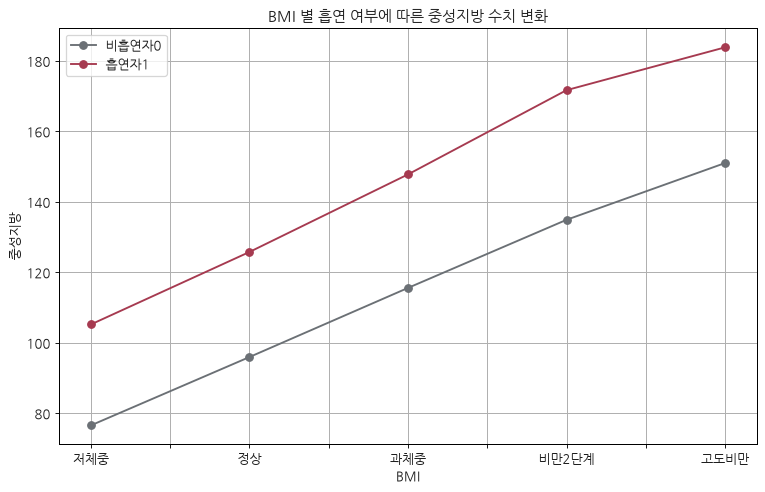

In [ ]:
bmi_smoking_t = train.groupby(['BMI_group', 'smoking'])['triglyceride'].mean().unstack()
bmi_smoking_t.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 중성 지방 수치 변화')
plt.xlabel('BMI')
plt.ylabel('triglyceride')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_t.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 중성지방 수치 변화")
plt.xlabel("BMI")
plt.ylabel("중성지방")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

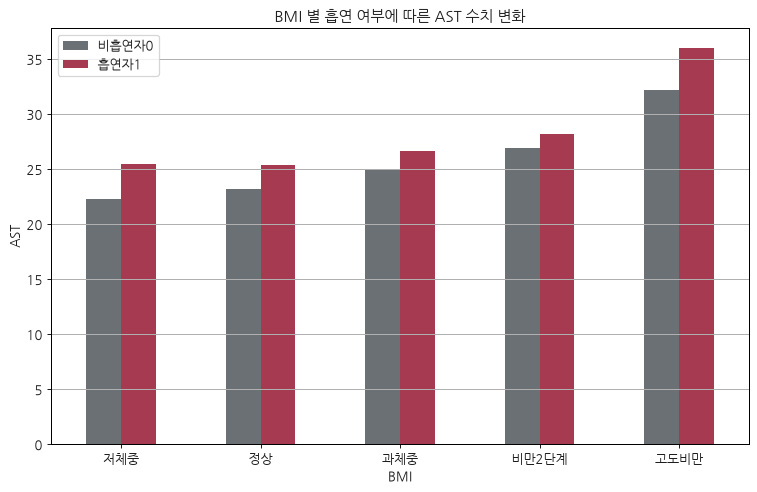

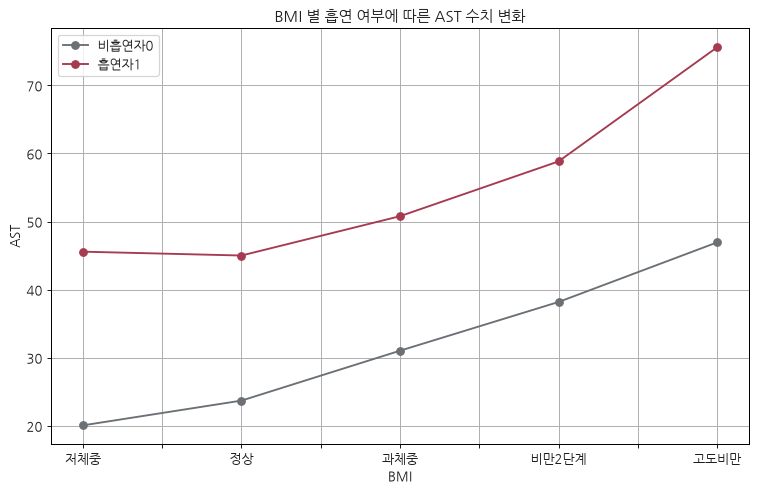

In [ ]:
bmi_smoking_ast = train.groupby(['BMI_group', 'smoking'])['AST'].mean().unstack()
bmi_smoking_ast.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 AST 수치 변화')
plt.xlabel('BMI')
plt.ylabel('AST')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 AST 수치 변화")
plt.xlabel("BMI")
plt.ylabel("AST")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

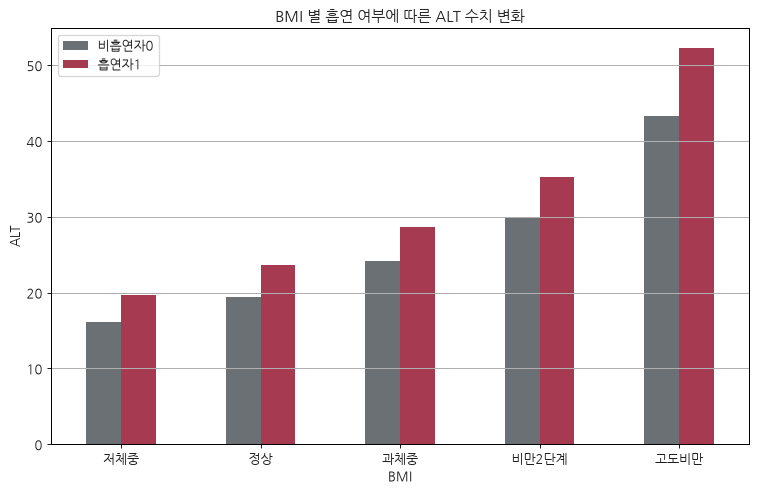

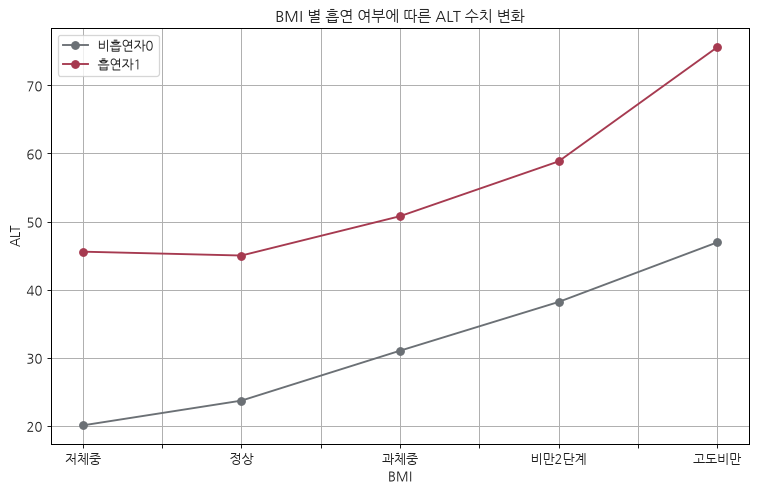

In [ ]:
bmi_smoking_alt = train.groupby(['BMI_group', 'smoking'])['ALT'].mean().unstack()
bmi_smoking_alt.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 ALT 수치 변화')
plt.xlabel('BMI')
plt.ylabel('ALT')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_gtp.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 ALT 수치 변화")
plt.xlabel("BMI")
plt.ylabel("ALT")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

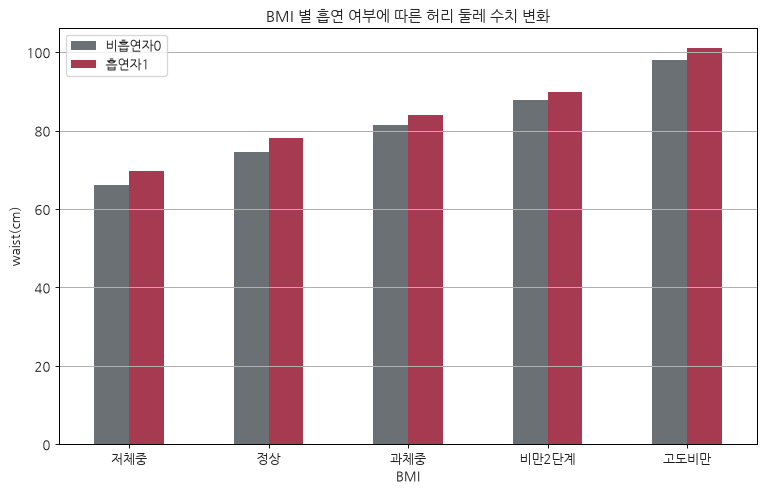

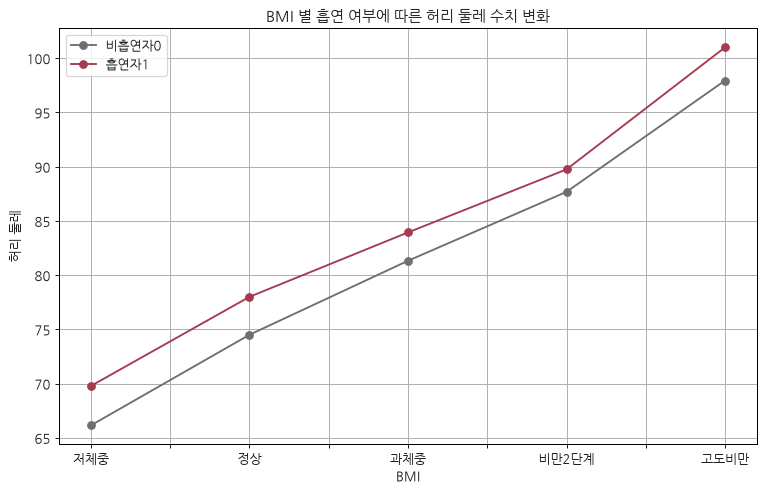

In [ ]:
bmi_smoking_w = train.groupby(['BMI_group', 'smoking'])['waist(cm)'].mean().unstack()
bmi_smoking_w.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 허리 둘레 수치 변화')
plt.xlabel('BMI')
plt.ylabel('waist(cm)')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()


bmi_smoking_w.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 허리 둘레 수치 변화")
plt.xlabel("BMI")
plt.ylabel("허리 둘레")
plt.grid(True)
plt.legend(['비흡연자0', '흡연자1'])
plt.show()

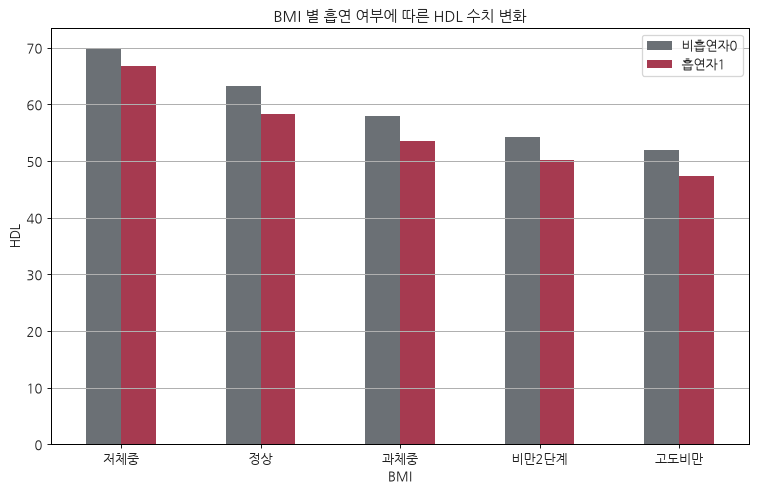

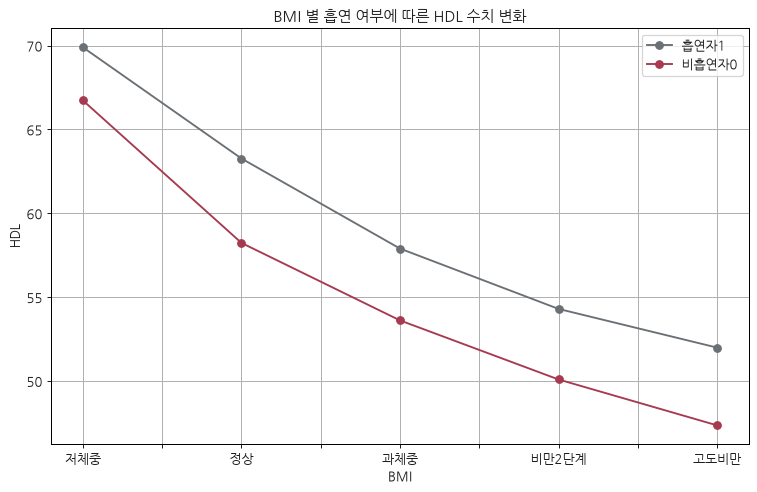

In [ ]:
bmi_smoking_h = train.groupby(['BMI_group', 'smoking'])['HDL'].mean().unstack()
bmi_smoking_h.plot(kind="bar", figsize=(10,6))
plt.title('BMI 별 흡연 여부에 따른 HDL 수치 변화')
plt.xlabel('BMI')
plt.ylabel('HDL')
plt.xticks(rotation=0)
plt.legend(['비흡연자0', '흡연자1'])
plt.grid(axis='y')
plt.show()

bmi_smoking_h.plot(kind ="line", figsize=(10,6), marker='o')
plt.title("BMI 별 흡연 여부에 따른 HDL 수치 변화")
plt.xlabel("BMI")
plt.ylabel("HDL")
plt.grid(True)
plt.legend(['흡연자1', '비흡연자0',])
plt.show()

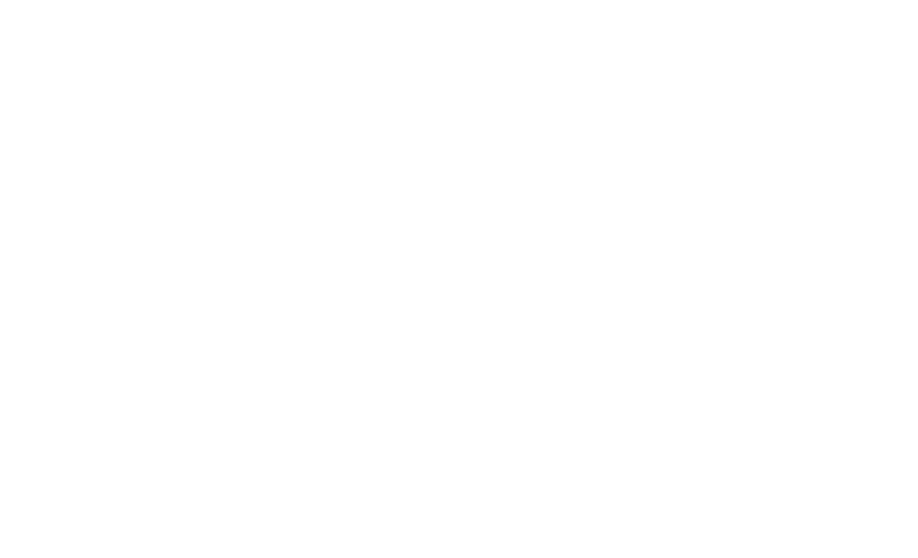

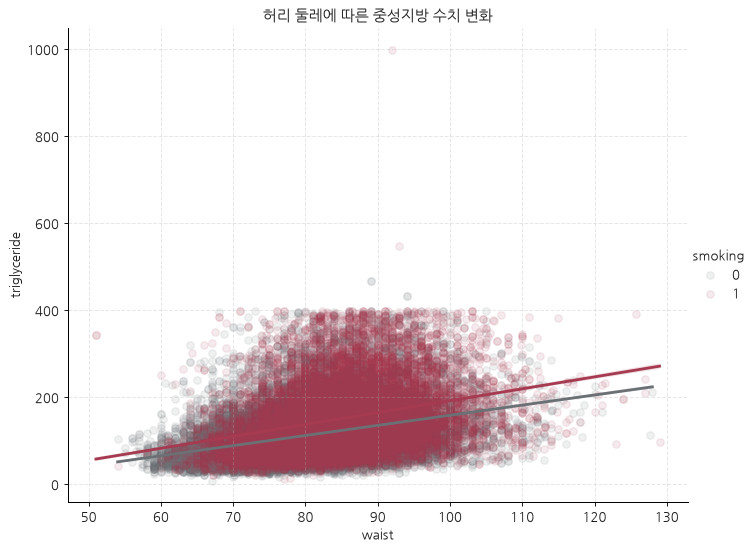

In [ ]:
#허리 둘레, 중성지방 산점도 그려보기
plt.figure(figsize=(10,6))
sns.lmplot(data=train, x='waist(cm)', y='triglyceride',hue='smoking',
           palette={0:C_NONSMOKER,1:C_SMOKER},
           scatter_kws={'alpha':0.1},
           height=6, aspect=1.3)
plt.title("허리 둘레에 따른 중성지방 수치 변화")
plt.xlabel("waist")
plt.ylabel("triglyceride")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

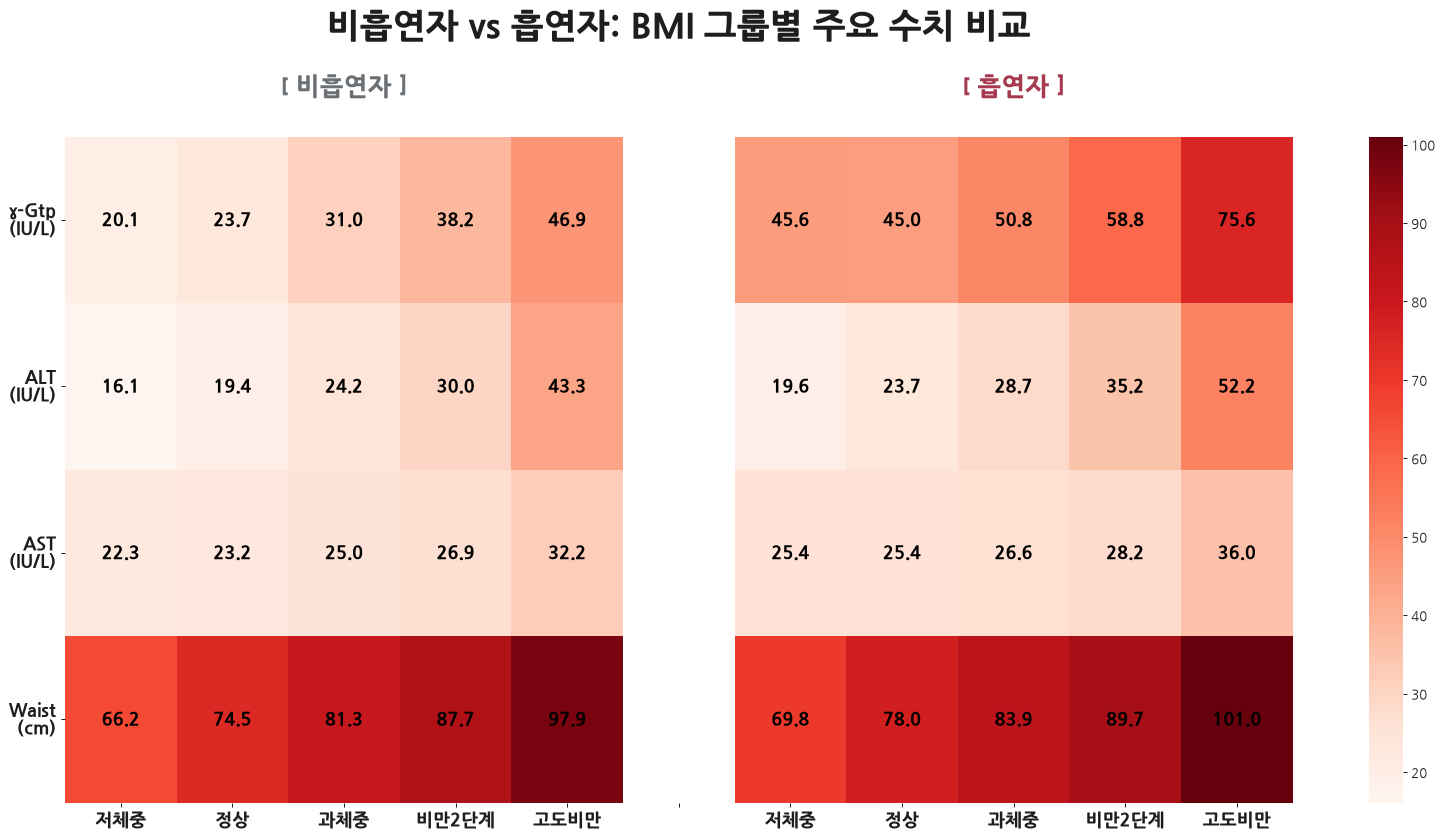

In [ ]:
target_cols = ['Gtp', 'ALT', 'AST', 'waist(cm)']
display_labels = ['γ-Gtp\n(IU/L)', 'ALT\n(IU/L)', 'AST\n(IU/L)', 'Waist\n(cm)']

smoker_no = train[train['smoking'] == 0].groupby('BMI_group', observed=False)[target_cols].mean()
smoker_yes = train[train['smoking'] == 1].groupby('BMI_group', observed=False)[target_cols].mean()

empty_col = pd.DataFrame([[np.nan] * len(target_cols)], index=[' '], columns=target_cols).T
df_combined_t = pd.concat([smoker_no.T, empty_col, smoker_yes.T], axis=1)

x_labels = list(smoker_no.index) + [' '] + list(smoker_yes.index)

fig = plt.figure(figsize=(22, 10), facecolor='none')
ax = sns.heatmap(df_combined_t, annot=True, fmt='.1f', cmap='Reds',
            annot_kws={'size': 14, 'weight': 'bold', 'color':'black'}, cbar_kws={'label': ''})

fig.patch.set_facecolor('none')
ax.set_facecolor('none')

plt.title('비흡연자 vs 흡연자: BMI 그룹별 주요 수치 비교', size=28, fontweight='bold', pad=80)

plt.xticks(np.arange(len(df_combined_t.columns)) + 0.5, x_labels, rotation=0, fontsize=14, fontweight='bold', color =C_TEXT)
plt.yticks(np.arange(len(target_cols)) + 0.5, display_labels, rotation=0, fontsize=14, fontweight='bold', color =C_TEXT)

plt.text(2.5, -0.3, '[ 비흡연자 ]', ha='center', va='center', fontsize=20, fontweight='bold', color=C_NONSMOKER)
plt.text(8.5, -0.3, '[ 흡연자 ]', ha='center', va='center', fontsize=20, fontweight='bold', color=C_SMOKER)

plt.subplots_adjust(top=0.85)
plt.xlabel('', labelpad=15)
plt.ylabel('', labelpad=15)
plt.show()

## 버전 B — 상호작용항 회귀분석 (OLS, robust SE)

=== GTP ===
                            OLS Regression Results                            
Dep. Variable:                    Gtp   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     1309.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:16:35   Log-Likelihood:            -1.9717e+05
No. Observations:               38740   AIC:                         3.943e+05
Df Residuals:                   38736   BIC:                         3.944e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           25.9569 

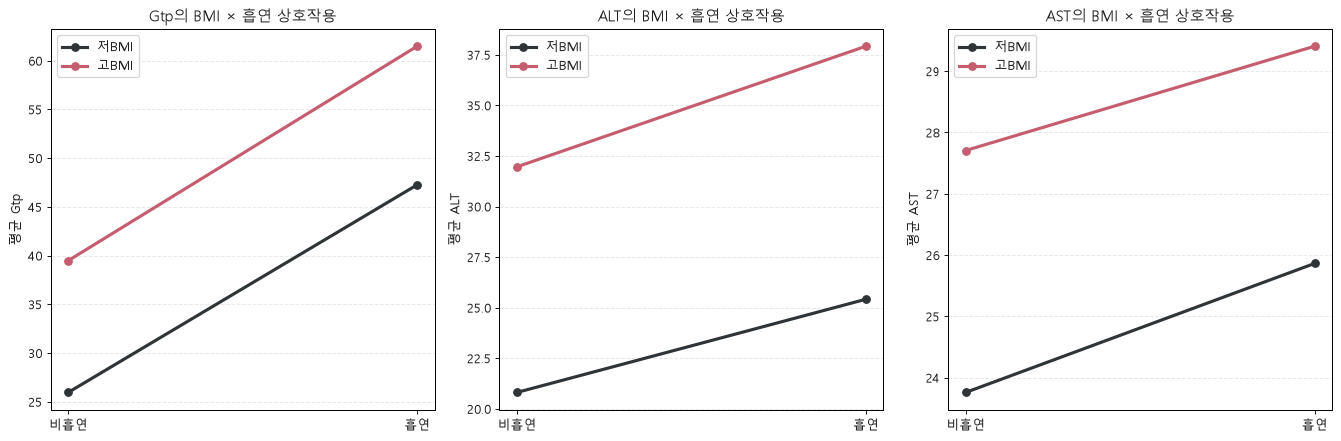

In [ ]:
#가설 3: 특히 고BMI 집단과 흡연이 결합하면 건강에 더 악영향을 줄 것이다
#가설 3-1_고BMI와 흡연이 결합하면 GTP, ALT, AST에 더 악영향을 줄 것이다
model_gtp = smf.ols('Gtp ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
model_alt = smf.ols('ALT ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
model_ast = smf.ols('AST ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
#상호작용 회귀분석 코드
print("=== GTP ===")
print(model_gtp.summary())

print("=== ALT ===")
print(model_alt.summary())

print("=== AST ===")
print(model_ast.summary())

#BMI 집단별 GTP, ALT, AST 평균 선그래프
interaction_vars = ['Gtp', 'ALT', 'AST']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, var in zip(axes, interaction_vars):
    temp = train_clean.groupby(['high_BMI','smoking'])[var].mean().unstack()

    ax.plot([0,1], temp.loc[0].values, marker='o', linewidth=2.5,
            color=COLOR_LOW_BMI, label='저BMI')
    ax.plot([0,1], temp.loc[1].values, marker='o', linewidth=2.5,
            color=COLOR_HIGH_BMI, label='고BMI')

    ax.set_xticks([0,1])
    ax.set_xticklabels(['비흡연', '흡연'])
    ax.set_title(f'{var}의 BMI × 흡연 상호작용', color=COLOR_TEXT)
    ax.set_ylabel(f'평균 {var}', color=COLOR_TEXT)
    ax.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:         Q("waist(cm)")   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                 1.011e+04
Date:                Wed, 12 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:16:35   Log-Likelihood:            -1.2984e+05
No. Observations:               38740   AIC:                         2.597e+05
Df Residuals:                   38736   BIC:                         2.597e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           76.3471      0.054  

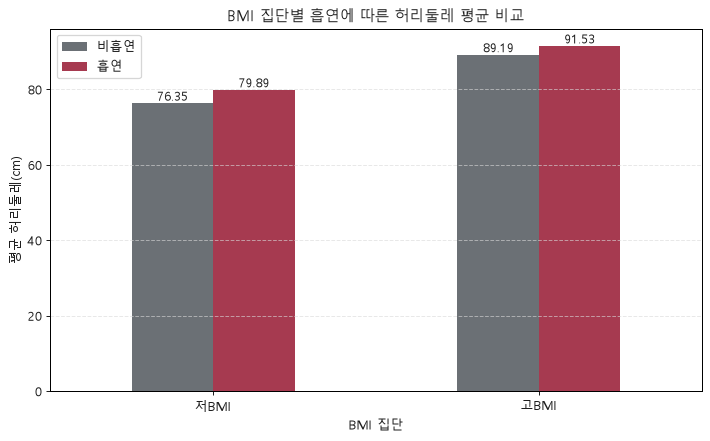

In [ ]:
#가설3-2_고BMI와 흡연이 결합하면 허리둘레(내장지방)에 더 악영향을 줄 것이다

#허리둘레 상호작용 회귀분석
model_waist = smf.ols('Q("waist(cm)") ~ smoking * high_BMI', data=train_clean).fit(cov_type='HC3')
print(model_waist.summary())

#허리둘레 막대그래프
waist_plot = train_clean.groupby(['high_BMI', 'smoking'])['waist(cm)'].mean().unstack()
waist_plot.index = ['저BMI', '고BMI']
waist_plot.columns = ['비흡연', '흡연']

ax = waist_plot.plot(
    kind='bar',
    figsize=(8,5),
    color=[COLOR_NONSMOKER, COLOR_SMOKER]
)

plt.title('BMI 집단별 흡연에 따른 허리둘레 평균 비교', color=COLOR_TEXT)
plt.xlabel('BMI 집단', color=COLOR_TEXT)
plt.ylabel('평균 허리둘레(cm)', color=COLOR_TEXT)
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.grid(axis='y', linestyle='--', color=COLOR_GRID, alpha=0.6)
plt.tight_layout()
plt.show()

## 버전 C — WHtR·중성지방·허리둘레 추가 분석

### 세부가설 2-5: BMI 및 흡연 여부에 따른 WHtR 및 중성지방 분석

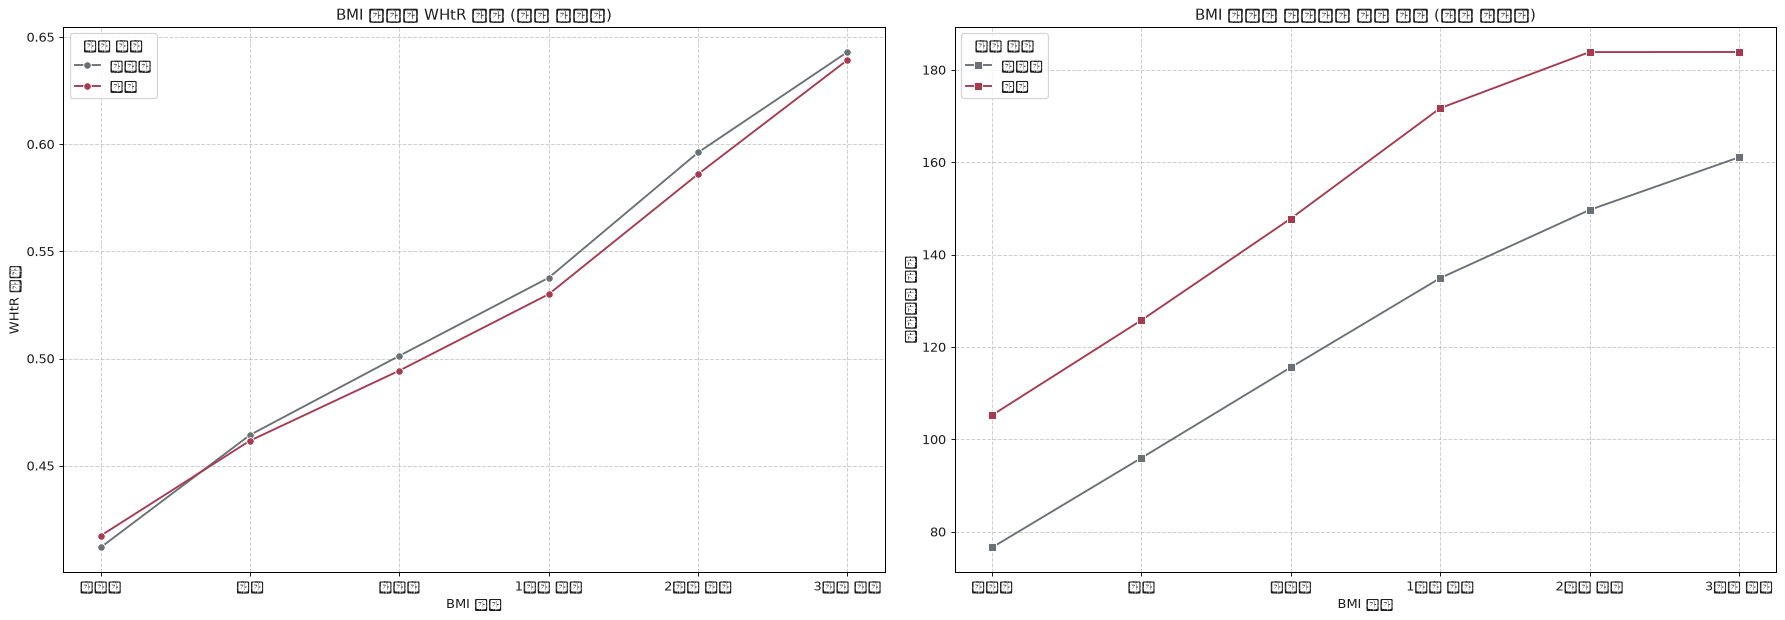

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# BMI 그룹 순서 정의
bmi_order = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. BMI 그룹별 WHtR (흡연 여부별)
sns.lineplot(ax=axes[0], data=train_clean, x='bmi_group', y='WHtR', hue='smoking', marker='o', errorbar=None)
axes[0].set_title('BMI 그룹별 WHtR 변화 (흡연 여부별)')
axes[0].set_xlabel('BMI 그룹')
axes[0].set_ylabel('WHtR 평균')
axes[0].legend(title='흡연 여부', labels=['비흡연', '흡연'])
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. BMI 그룹별 중성지방 (Triglyceride) (흡연 여부별)
sns.lineplot(ax=axes[1], data=train_clean, x='bmi_group', y='triglyceride', hue='smoking', marker='s', errorbar=None)
axes[1].set_title('BMI 그룹별 중성지방 수치 변화 (흡연 여부별)')
axes[1].set_xlabel('BMI 그룹')
axes[1].set_ylabel('중성지방 평균')
axes[1].legend(title='흡연 여부', labels=['비흡연', '흡연'])
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
whtr_trig_table = train_clean.groupby(['bmi_group', 'smoking'], observed=False)[['WHtR', 'triglyceride']].mean().unstack()
print("--- BMI 그룹별 WHtR 및 중성지방 평균 ---")
display(whtr_trig_table.round(3))

--- BMI 그룹별 WHtR 및 중성지방 평균 ---
            WHtR        triglyceride         
smoking        0      1            0        1
bmi_group                                    
저체중        0.412  0.417       76.589  105.232
정상         0.464  0.462       95.976  125.789
과체중        0.501  0.494      115.588  147.799
1단계 비만     0.538  0.530      134.912  171.701
2단계 비만     0.596  0.586      149.671  183.848
3단계 비만     0.643  0.639      161.058  183.870


### 세부가설 2-6: 허리둘레와 중성지방의 상관관계 분석

허리둘레와 중성지방 간의 전체 상관계수: 0.3610


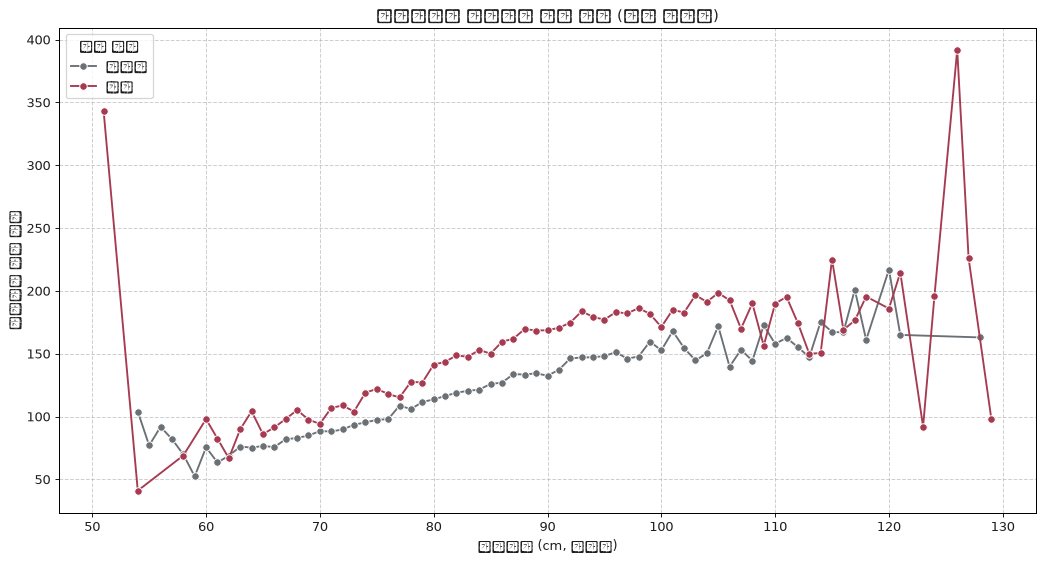

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 허리둘레를 정수 단위로 반올림하여 그룹화 (선 그래프 시각화를 위해)
train_clean['waist_round'] = train_clean['waist(cm)'].round(0)

plt.figure(figsize=(14, 7))
sns.lineplot(data=train_clean, x='waist_round', y='triglyceride', hue='smoking', marker='o', errorbar=None)

plt.title('허리둘레별 중성지방 수치 변화 (흡연 여부별)')
plt.xlabel('허리둘레 (cm, 반올림)')
plt.ylabel('중성지방 평균 수치')
plt.legend(title='흡연 여부', labels=['비흡연', '흡연'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 상관계수 계산 및 출력
waist_trig_corr = train_clean[['waist(cm)', 'triglyceride']].corr().iloc[0, 1]
print(f'허리둘레와 중성지방 간의 전체 상관계수: {waist_trig_corr:.4f}')

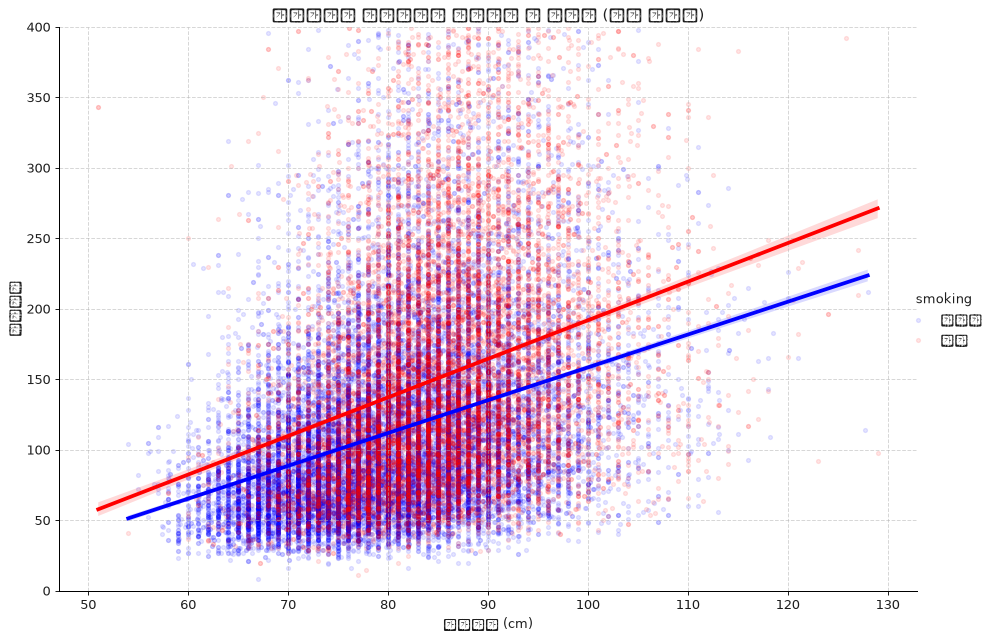

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'smoking' 값의 의미를 명확히 하여 그래프 생성 (0: 비흡연, 1: 흡연)
# y축 범위를 400으로 제한하여 가독성 향상
g = sns.lmplot(data=train_clean, x='waist(cm)', y='triglyceride', hue='smoking',
               hue_order=[0, 1], palette={0: 'blue', 1: 'red'},
               scatter_kws={'alpha':0.1, 's':10}, line_kws={'linewidth':3},
               aspect=1.5, height=7)

plt.title('허리둘레와 중성지방의 상관관계 및 추세선 (흡연 여부별)')
plt.xlabel('허리둘레 (cm)')
plt.ylabel('중성지방')

# Y축 범위 제한
plt.ylim(0, 400)

# 범례 텍스트와 색상을 명확하게 수정
new_labels = ['비흡연', '흡연']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()